# OCR Prior — Recall / Coverage Check (DocTamper)

Verifies the **OCR text prior** *before* any training — the TA's headline ask. The OCR mask is a
region-proposal stage, so we measure how well it **covers the tampered regions** (recall). A missed
forged region cannot be recovered downstream.

**Safety:** this notebook does **not** load any DocTamper checkpoint (`.pth`) or pickle (`.pk`). It only
reads `(image, tamper_mask)` pairs from the LMDB (using DocTamper's documented key format) and runs a
*pretrained* OCR detector. No `torch.load` / `pickle.load` of upstream files.

**Flow:** clone our repo → **unzip** the DocTamperV1-FCD archive you downloaded to Drive (password from
the author's email) → read LMDB → build `M_text` with pretrained EasyOCR → `OCRCoverageMeter`
→ qualitative overlays.

> You download the official zip yourself (from the author's Drive link) and put it on your Drive; this
> notebook only unzips it.

In [1]:
# --- Setup: mount Drive, clone our repo, install lightweight deps ---
from google.colab import drive
drive.mount('/content/drive')

import os, sys
%cd /content
if not os.path.exists('/content/HLCV-Project'):
    !git clone https://github.com/SamiraAbedini/HLCV-Project.git

# Only what the OCR-recall check needs. DocTamper code itself is NOT cloned or run here.
!pip -q install lmdb easyocr opencv-python-headless pillow six tqdm

sys.path.append('/content/HLCV-Project')
print('setup done')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
setup done


In [2]:
# --- Unzip the DocTamper archive you downloaded to Drive ---
# You download the official zip yourself and place it on your Drive; this cell
# unzips it with the password (typed via getpass, never written to the notebook).
import os, glob, getpass

ZIP_PATH = '/content/drive/MyDrive/DocTamperV1-FCD.zip'  # <-- set to where YOUR zip is
WORK     = '/content/data'                               # extracted LMDB target (this session)
os.makedirs(WORK, exist_ok=True)

assert os.path.exists(ZIP_PATH), f'Archive not found: {ZIP_PATH} (edit ZIP_PATH to your zip).'

# Unzip only if not already extracted this session.
if not glob.glob(os.path.join(WORK, '**', 'data.mdb'), recursive=True):
    pw = getpass.getpass('DocTamper zip password: ')   # typed now, not stored
    !unzip -P "$pw" "{ZIP_PATH}" -d "{WORK}"
    del pw

# Locate the LMDB folder (the dir containing data.mdb), regardless of nesting.
mdbs = glob.glob(os.path.join(WORK, '**', 'data.mdb'), recursive=True)
assert mdbs, 'Unzip did not produce a data.mdb — check the password and the archive.'
DATA_DIR = os.path.dirname(mdbs[0])
print('LMDB folder ready:', DATA_DIR)

LMDB folder ready: /content/data/DocTamperV1-FCD


In [3]:
# --- Config + LMDB reader (DocTamper key format: image-%09d / label-%09d) ---
# Uses DATA_DIR set by the download cell above.
import io, lmdb, cv2, numpy as np
from PIL import Image

# Step 3: number of images to evaluate. Set to None to use the FULL split
# (more stable numbers, but slow — EasyOCR is the bottleneck).
N_SAMPLES = 200

assert 'DATA_DIR' in globals() and os.path.exists(DATA_DIR), 'Run the download cell first.'
print('using DATA_DIR =', DATA_DIR)

env = lmdb.open(DATA_DIR, readonly=True, lock=False, readahead=False, meminit=False)
with env.begin(write=False) as txn:
    num_samples = int(txn.get(b'num-samples'))
print('num-samples in dataset:', num_samples)

def read_sample(index):
    """Return (rgb_uint8 HxWx3, tamper_mask_bool HxW)."""
    with env.begin(write=False) as txn:
        imgbuf = txn.get(('image-%09d' % index).encode('utf-8'))
        lblbuf = txn.get(('label-%09d' % index).encode('utf-8'))
    image = np.array(Image.open(io.BytesIO(imgbuf)).convert('RGB'))
    mask = cv2.imdecode(np.frombuffer(lblbuf, dtype=np.uint8), 0)
    tamper = mask > 0   # binary tampered region (handles 0/1 and 0/255 encodings)
    return image, tamper

img0, m0 = read_sample(0)
print('image', img0.shape, '| mask', m0.shape, '| tampered px', int(m0.sum()))

using DATA_DIR = /content/data/DocTamperV1-FCD
num-samples in dataset: 2000
image (512, 512, 3) | mask (512, 512) | tampered px 1004


In [4]:
# --- Pretrained OCR detector -> M_text (no training, per TA feedback) ---
import easyocr
from src.text_prior import OCRTextMasker

reader = easyocr.Reader(['en'], gpu=True)   # downloads its own pretrained detector weights

def easyocr_detector(image_np):
    # EasyOCR returns [(quad_points, text, conf), ...]; keep the quad polygons.
    results = reader.readtext(image_np, detail=1, paragraph=False)
    return [pts for (pts, text, conf) in results]

# `dilate` grows the text mask a few px -> higher recall. This is the main knob
# for the region-proposal high-recall target; tune it against the metrics below.
masker = OCRTextMasker(easyocr_detector, polygon=True, dilate=5)

tm0 = masker(img0)
print('text-mask area fraction on sample 0:', float((tm0 > 0).mean()))

text-mask area fraction on sample 0: 0.8091049194335938


In [5]:
# --- Aggregate OCR recall/coverage over the split ---
from src.ocr_eval import OCRCoverageMeter
from tqdm import tqdm

meter = OCRCoverageMeter(coverage_thresh=0.5)
n = num_samples if N_SAMPLES is None else min(N_SAMPLES, num_samples)   # Step 3: None = full split
for i in tqdm(range(n)):
    image, tamper = read_sample(i)
    if tamper.sum() == 0:
        continue                      # skip authentic images (nothing to cover)
    text_mask = masker(image)
    meter.update(text_mask, tamper)

metrics = meter.compute()
print('\n=== OCR prior vs tampered regions (n=%d) ===' % n)
for k, v in metrics.items():
    print(f'{k:28s}: {v:.4f}')

100%|██████████| 200/200 [01:03<00:00,  3.15it/s]


=== OCR prior vs tampered regions (n=200) ===
pixel_recall_coverage       : 0.9877
component_recall            : 0.9494
text_area_ratio             : 0.8023
num_tampered_components     : 514.0000
num_covered_components      : 488.0000


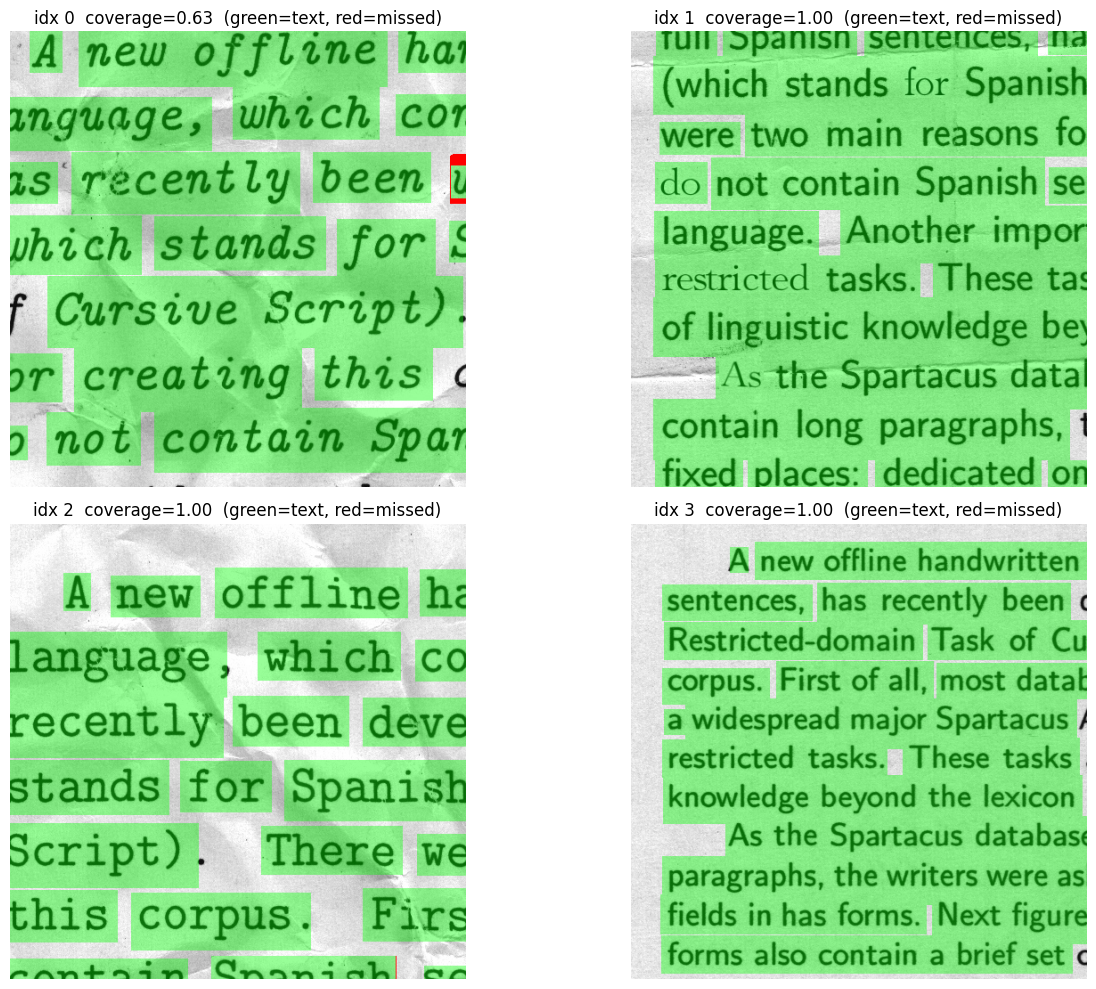

In [6]:
# --- Qualitative: where does the OCR prior MISS tampered regions? ---
import matplotlib.pyplot as plt

def overlay(image, tamper, text_mask):
    vis = image.copy()
    t = text_mask > 0
    vis[t] = (0.6 * vis[t] + 0.4 * np.array([0, 255, 0])).astype(np.uint8)  # text = green
    miss = tamper & ~t
    vis[miss] = np.array([255, 0, 0], dtype=np.uint8)   # missed tampered px = red (unrecoverable!)
    return vis

shown, i = 0, 0
plt.figure(figsize=(14, 10))
while shown < 4 and i < num_samples:
    image, tamper = read_sample(i); i += 1
    if tamper.sum() == 0:
        continue
    tmask = masker(image)
    cov = (tamper & (tmask > 0)).sum() / max(1, tamper.sum())
    plt.subplot(2, 2, shown + 1)
    plt.imshow(overlay(image, tamper, tmask))
    plt.title(f'idx {i-1}  coverage={cov:.2f}  (green=text, red=missed)')
    plt.axis('off')
    shown += 1
plt.tight_layout(); plt.show()

## Steps 1–3: deeper OCR-module analysis

The OCR **detection** is the slow part, so we cache it once and apply dilation cheaply on top — making
the sweep and miss-inspection fast.

- **Step 3 (full split):** set `N_SAMPLES = None` in the config cell to evaluate every image (slower).
- **Step 2 (sweep):** recall ↔ search-space-area trade-off across `dilate` values — the precision/recall
  picture for the region-proposal argument.
- **Step 1 (misses):** the tampered components the prior fails to cover, and whether they are tiny edits
  or non-text tampering.

In [7]:
# --- Cache OCR detections once (detection is slow; dilation is cheap) ---
# Lets Steps 1-2 reuse the same boxes and only vary the dilation, so they are fast.
from src.text_prior import polygons_to_mask

EVAL_N = num_samples if N_SAMPLES is None else min(N_SAMPLES, num_samples)
cache = {}   # index -> (polys, (H, W), tamper_bool)
for i in tqdm(range(EVAL_N), desc='OCR detect'):
    image, tamper = read_sample(i)
    if tamper.sum() == 0:
        continue                       # skip authentic images
    cache[i] = (easyocr_detector(image), image.shape[:2], tamper)
print('cached detections for', len(cache), 'tampered images')

def mask_from_cache(polys, hw, dilate):
    """Rebuild the text mask from cached polygons at a given dilation (returns bool HxW)."""
    h, w = hw
    m = polygons_to_mask(polys, h, w) if polys else np.zeros((h, w), np.uint8)
    if dilate > 0:
        m = cv2.dilate(m, np.ones((dilate, dilate), np.uint8), iterations=1)
    return m > 0

OCR detect: 100%|██████████| 200/200 [00:53<00:00,  3.76it/s]

cached detections for 200 tampered images


dilate  pixel_recall  comp_recall  area_ratio
     0        0.9825       0.9475      0.7569
     2        0.9837       0.9494      0.7684
     5        0.9877       0.9494      0.8023
    10        0.9909       0.9494      0.8479


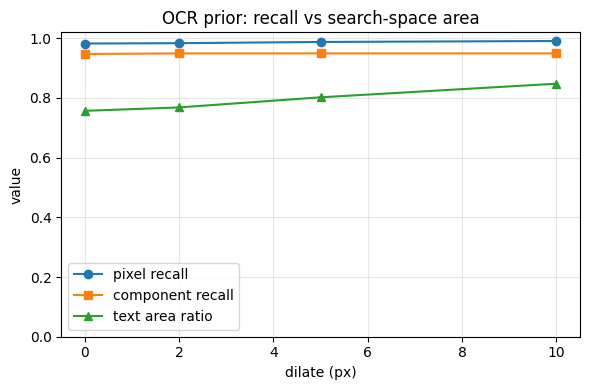

In [8]:
# --- Step 2: recall <-> area trade-off across dilation values ---
import matplotlib.pyplot as plt
from src.ocr_eval import OCRCoverageMeter

DILATIONS = [0, 2, 5, 10]
rows = {}
print(f'{"dilate":>6} {"pixel_recall":>13} {"comp_recall":>12} {"area_ratio":>11}')
for d in DILATIONS:
    meter_d = OCRCoverageMeter(coverage_thresh=0.5)
    for polys, hw, tamper in cache.values():
        meter_d.update(mask_from_cache(polys, hw, d), tamper)
    r = meter_d.compute(); rows[d] = r
    print(f'{d:>6} {r["pixel_recall_coverage"]:>13.4f} {r["component_recall"]:>12.4f} {r["text_area_ratio"]:>11.4f}')

plt.figure(figsize=(6, 4))
plt.plot(DILATIONS, [rows[d]['pixel_recall_coverage'] for d in DILATIONS], 'o-', label='pixel recall')
plt.plot(DILATIONS, [rows[d]['component_recall'] for d in DILATIONS], 's-', label='component recall')
plt.plot(DILATIONS, [rows[d]['text_area_ratio'] for d in DILATIONS], '^-', label='text area ratio')
plt.xlabel('dilate (px)'); plt.ylabel('value'); plt.ylim(0, 1.02)
plt.legend(); plt.grid(alpha=0.3); plt.title('OCR prior: recall vs search-space area')
plt.tight_layout(); plt.show()

missed components (coverage < 0.5) at dilate=5: 26
  component area px -> min 36, median 205, max 3485
  tiny (<200 px): 42%  (often single small edits)


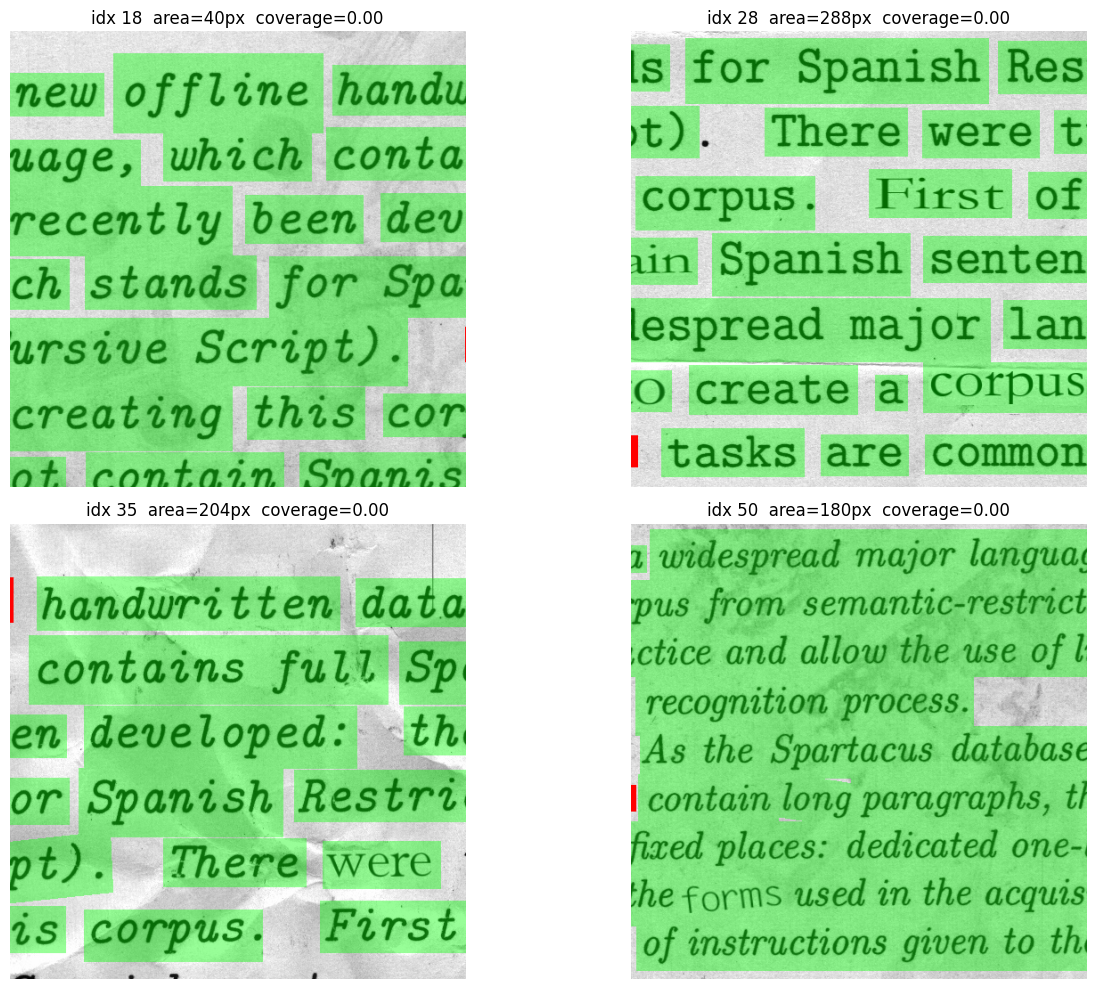


Inspect the red regions: tiny single-character edits vs NON-text tampering (stamps / signatures / lines) the OCR detector structurally cannot propose.


In [9]:
# --- Step 1: inspect MISSED tampered regions (the unrecoverable failures) ---
OP_DILATE = 5   # operating point; pick the dilate you chose from the sweep above

missed = []   # (img_index, comp_bool, coverage, area_px)
for i, (polys, hw, tamper) in cache.items():
    tmask = mask_from_cache(polys, hw, OP_DILATE)
    num, labels = cv2.connectedComponents(tamper.astype(np.uint8), connectivity=8)
    for c in range(1, num):
        comp = labels == c
        area = int(comp.sum())
        cov = int((comp & tmask).sum()) / max(1, area)
        if cov < 0.5:
            missed.append((i, comp, cov, area))

missed.sort(key=lambda m: m[2])   # worst coverage first
print(f'missed components (coverage < 0.5) at dilate={OP_DILATE}: {len(missed)}')
if missed:
    areas = np.array([m[3] for m in missed])
    print(f'  component area px -> min {areas.min()}, median {int(np.median(areas))}, max {areas.max()}')
    print(f'  tiny (<200 px): {(areas < 200).mean()*100:.0f}%  (often single small edits)')

    plt.figure(figsize=(14, 10))   # show the 4 worst-covered misses
    for k, (i, comp, cov, area) in enumerate(missed[:4]):
        image, _ = read_sample(i)
        polys, hw, _ = cache[i]
        tmask = mask_from_cache(polys, hw, OP_DILATE)
        vis = image.copy()
        vis[tmask] = (0.6 * vis[tmask] + 0.4 * np.array([0, 255, 0])).astype(np.uint8)
        vis[comp] = np.array([255, 0, 0], np.uint8)
        plt.subplot(2, 2, k + 1); plt.imshow(vis)
        plt.title(f'idx {i}  area={area}px  coverage={cov:.2f}')
        plt.axis('off')
    plt.tight_layout(); plt.show()
    print('\nInspect the red regions: tiny single-character edits vs NON-text tampering '
          '(stamps / signatures / lines) the OCR detector structurally cannot propose.')

## Reading the results

- **`pixel_recall_coverage` / `component_recall`** — the headline numbers. As a region-proposal stage the
  prior should score high here; **red pixels** in the overlays are tampered regions it missed
  (unrecoverable downstream).
- **`text_area_ratio`** — how much of the image the prior keeps as "search space". Lower is better *at
  equal recall* (the precision / efficiency side of the trade-off).

**If recall is low:** raise `OCRTextMasker(dilate=...)`, lower EasyOCR's confidence threshold, or add
languages — then re-run. Only once recall is satisfactory does fusing the prior and training make sense
(Phase 1 in [`docs/INTEGRATION.md`](../docs/INTEGRATION.md)).

Report these numbers (quantitative) plus a couple of overlays (qualitative) in the presentation — exactly
the OCR-module evaluation the TA asked for.